In [25]:
import pandas as pd

In [26]:
df=pd.read_csv('Fish.csv')

In [27]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [28]:
corr_matrix=df.corr(numeric_only=True)

In [29]:
corr_matrix

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000


In [30]:
import matplotlib.pyplot as plt

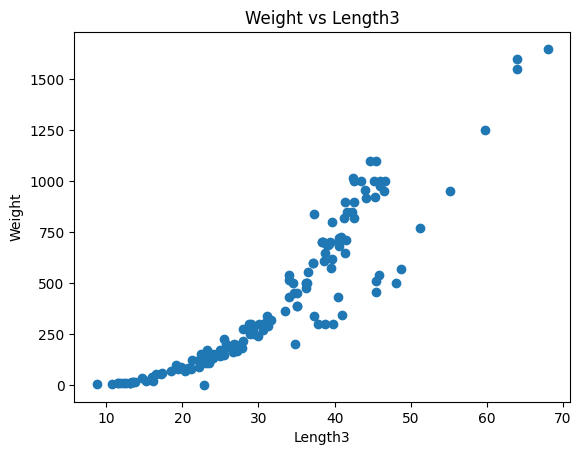

In [31]:
plt.scatter(df["Length3"], df["Weight"])
plt.xlabel("Length3")
plt.ylabel("Weight")
plt.title("Weight vs Length3")
plt.show()

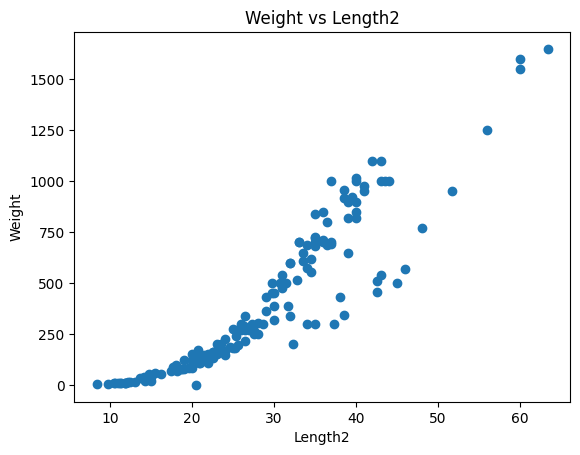

In [32]:
plt.scatter(df["Length2"], df["Weight"])
plt.xlabel("Length2")
plt.ylabel("Weight")
plt.title("Weight vs Length2")
plt.show()

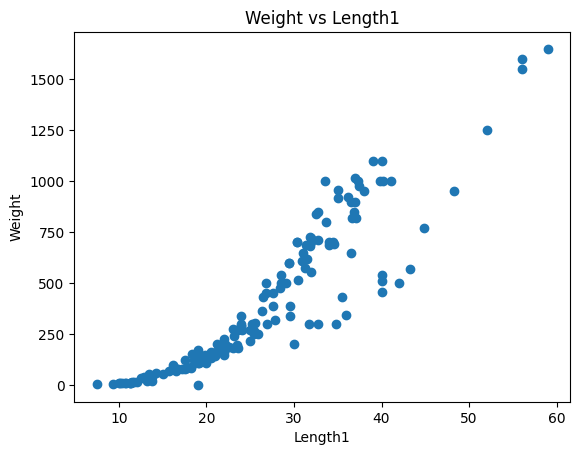

In [33]:
plt.scatter(df["Length1"], df["Weight"])
plt.xlabel("Length1")
plt.ylabel("Weight")
plt.title("Weight vs Length1")
plt.show()

In [34]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

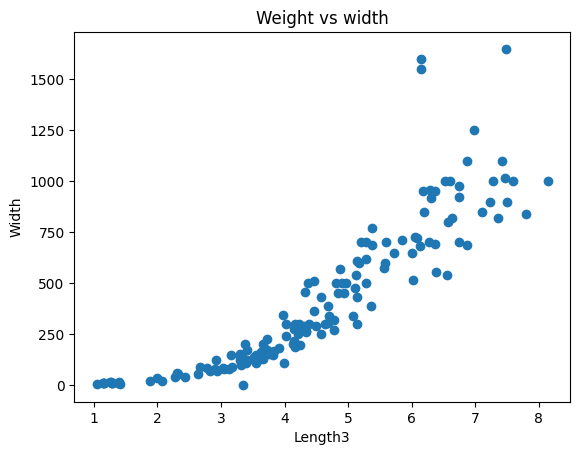

In [35]:
plt.scatter(df["Width"], df["Weight"])
plt.xlabel("Length3")
plt.ylabel("Width")
plt.title("Weight vs width")
plt.show()

In [36]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [38]:
x=df[['Length3']]
y=df['Weight']
model=LinearRegression()

In [39]:
xtrain, xtest, ytrain, ytest= train_test_split(x,y, train_size=0.8, random_state=42)

In [40]:
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
model.coef_

array([28.4601708])

In [42]:
model.intercept_

-490.4005915891796

In [43]:
from sklearn.preprocessing import PolynomialFeatures

In [44]:
poly=PolynomialFeatures(degree=8)
updated_xtrain=poly.fit_transform(xtrain)
updated_xtest= poly.transform(xtest)
print(updated_xtrain)

[[1.00000000e+00 1.72000000e+01 2.95840000e+02 ... 2.58923030e+07
  4.45347612e+08 7.65997893e+09]
 [1.00000000e+00 4.87000000e+01 2.37169000e+03 ... 1.33405510e+10
  6.49684833e+11 3.16396514e+13]
 [1.00000000e+00 3.11000000e+01 9.67210000e+02 ... 9.04820297e+08
  2.81399112e+10 8.75151239e+11]
 ...
 [1.00000000e+00 3.72000000e+01 1.38384000e+03 ... 2.65007179e+09
  9.85826706e+10 3.66727535e+12]
 [1.00000000e+00 2.40000000e+01 5.76000000e+02 ... 1.91102976e+08
  4.58647142e+09 1.10075314e+11]
 [1.00000000e+00 2.87000000e+01 8.23690000e+02 ... 5.58845014e+08
  1.60388519e+10 4.60315049e+11]]


In [45]:
model=LinearRegression()
model.fit(updated_xtrain, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


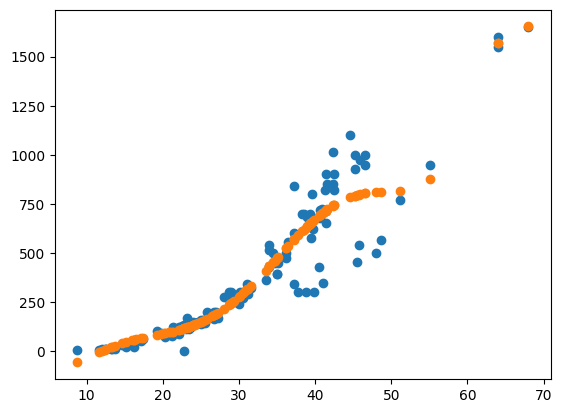

In [46]:
y_pred_train = model.predict(updated_xtrain)
plt.scatter(updated_xtrain[:,1],ytrain)
plt.scatter(updated_xtrain[:,1],y_pred_train)

In [47]:
# Train Data
from sklearn.metrics import r2_score
train_score=r2_score(ytrain, y_pred_train)
print(f"train_score: {train_score}")

train_score: 0.8992237417685787


In [48]:
y_pred_test=model.predict(updated_xtest)
test_score=r2_score(ytest, y_pred_test)
print(f'test_score: {test_score}')

test_score: 0.8921849571032849


### Observation:

### When degree=2
### train_score: 0.8756695367609073
### test_score: 0.8664863426509607


### When degree=3
### train_score: 0.8805809992691505
### test_score: 0.8862094896219262


### When degree=4
### train_score: 0.8856496868844017
### test_score: 0.8812441993635196


### When degree=5
### train_score: 0.8879549049722888
### test_score: 0.8881476812200615


### When degree=6
### train_score: 0.8912086209863554
### test_score: 0.8815099275120191

### When degree=7
### train_score: 0.8958944384417463
### test_score: 0.8854095183510116

### When degree=8
### train_score: 0.8992237417685821
### test_score: 0.8921849571032461

### From above datasets we conclude that, the model is good fit and suitable degree is 5

In [49]:
import pandas as pd

In [50]:
df1=pd.read_csv('Salary_Data.csv')

In [51]:
df1

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [52]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


In [53]:
df1.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


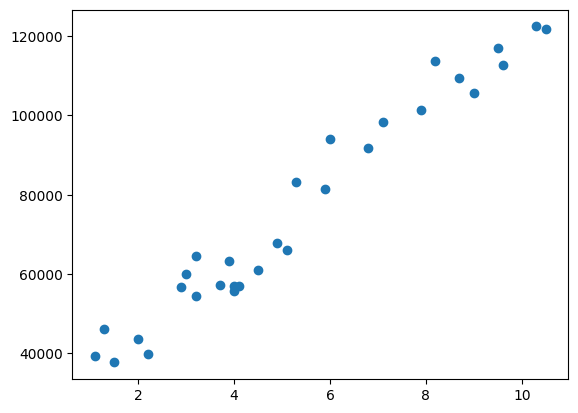

In [54]:
plt.scatter(df1['YearsExperience'],df1['Salary'])

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [56]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [57]:
x1=df1[['YearsExperience']]
y1=df1['Salary']

In [58]:
x_train, x_test, y_train, y_test=train_test_split(x1,y1, train_size=0.8, random_state=42)

In [59]:
scaler=StandardScaler()

In [61]:
updated_x_train=scaler.fit_transform(x_train)

In [62]:
updated_x_test=scaler.transform(x_test)

In [68]:
print(updated_x_train, x_train)

[[ 1.77445774]
 [ 1.21912622]
 [-0.41216011]
 [-1.41869849]
 [-1.03690807]
 [-0.03036969]
 [-0.79395053]
 [-0.37745189]
 [-0.41216011]
 [ 0.94146047]
 [-1.34928205]
 [-1.27986561]
 [ 1.32325088]
 [-1.10632451]
 [ 0.66379471]
 [ 1.49679198]
 [ 0.24729607]
 [ 1.84387418]
 [ 0.55967005]
 [-0.68982587]
 [-0.44686833]
 [-0.23861901]
 [ 0.28200429]
 [-0.75924231]]     YearsExperience
28             10.3
24              8.7
12              4.0
0               1.1
4               2.2
16              5.1
5               2.9
13              4.1
11              4.0
22              7.9
1               1.3
2               1.5
25              9.0
3               2.0
21              7.1
26              9.5
18              5.9
29             10.5
20              6.8
7               3.2
10              3.9
14              4.5
19              6.0
6               3.0


In [69]:
print(updated_x_test, x_test)

[[ 1.5315002 ]
 [-0.09978613]
 [ 1.04558513]
 [ 0.03904675]
 [-0.68982587]
 [-0.51628477]]     YearsExperience
27              9.6
15              4.9
23              8.2
17              5.3
8               3.2
9               3.7


In [70]:
scaler1=RobustScaler()

In [71]:
updated_x_train_Robust=scaler.fit_transform(x_train)

In [72]:
updated_x_test_Robust=scaler.transform(x_test)

In [73]:
print(updated_x_train_Robust, x_train)

[[ 1.77445774]
 [ 1.21912622]
 [-0.41216011]
 [-1.41869849]
 [-1.03690807]
 [-0.03036969]
 [-0.79395053]
 [-0.37745189]
 [-0.41216011]
 [ 0.94146047]
 [-1.34928205]
 [-1.27986561]
 [ 1.32325088]
 [-1.10632451]
 [ 0.66379471]
 [ 1.49679198]
 [ 0.24729607]
 [ 1.84387418]
 [ 0.55967005]
 [-0.68982587]
 [-0.44686833]
 [-0.23861901]
 [ 0.28200429]
 [-0.75924231]]     YearsExperience
28             10.3
24              8.7
12              4.0
0               1.1
4               2.2
16              5.1
5               2.9
13              4.1
11              4.0
22              7.9
1               1.3
2               1.5
25              9.0
3               2.0
21              7.1
26              9.5
18              5.9
29             10.5
20              6.8
7               3.2
10              3.9
14              4.5
19              6.0
6               3.0
